In [1]:
"""
This script trims FITS images for sextractor comparative photometry analysis
by creating a new FITS object based on a
cutout of the original data, ensuring all cutouts are the same pixel size.
"""

import numpy as np
from astropy.io import fits
from astropy.coordinates import SkyCoord
import astropy.units as u
from astropy.wcs import WCS
from astropy.nddata import Cutout2D


def read_in_fits(infile: str) -> tuple[fits.HDUList, WCS]:
    """
    Reads in the FITS file from the given input file path.
    """
    hdu = fits.open(infile)
    wcs = WCS(hdu[1].header)
    return hdu, wcs

def make_new_fits_file(hdu: fits.hdu.hdulist.HDUList, cutout_object: Cutout2D, outfile: str) -> None:
    """
    Writes the cutout to a new FITS file.
    """
    new_primary = fits.PrimaryHDU()
    new_image = fits.ImageHDU(data=cutout_object.data, header=hdu[1].header)
    new_image.header.update(cutout_object.wcs.to_header())
    new_hdul = fits.HDUList([new_primary, new_image])
    new_hdul.writeto(outfile, overwrite=True)

def cut_fits_image_pixel(fits_image: str, position: SkyCoord, size_pix: tuple[int, int], outfile: str) -> None:
    """
    Cuts a FITS image to a specific pixel size at a given sky position.
    """
    hdu, wcs = read_in_fits(fits_image)
    cutout = Cutout2D(hdu[1].data, position, size_pix, wcs=wcs,mode='trim')
    make_new_fits_file(hdu, cutout, outfile)

def get_center_of_image(fits_name: str) -> SkyCoord:
    """
    Returns the sky coordinates of the center of the image.
    """
    hdu = fits.open(fits_name)
    data = hdu[1].data
    y_pix, x_pix = data.shape[0] / 2, data.shape[1] / 2
    wcs = WCS(hdu[1].header)
    ra, dec = wcs.pixel_to_world_values(x_pix, y_pix)
    print(f"RA: {ra}, DEC: {dec}")
    return SkyCoord(ra * u.deg, dec * u.deg)

if __name__ == '__main__':
    INFILE_I = '/Users/aishwarya/Documents/Lyman_alpha/I/c4d_211021_003551_osj_i_vik2.fits.fz'
    INFILE_I_WEIGHT = '/Users/aishwarya/Documents/Lyman_alpha/I/c4d_211021_003551_osw_i_vik2.fits.fz'

    INFILE_Z = '/Users/aishwarya/Documents/Lyman_alpha/Z/c4d_210831_053503_osj_z_vik2.fits.fz'
    INFILE_Z_WEIGHT = '/Users/aishwarya/Documents/Lyman_alpha/Z/c4d_210831_053503_osw_z_vik2.fits.fz'

    INFILE_N964 = '/Users/aishwarya/Documents/Lyman_alpha/N964/c4d_210831_050404_osj_N964_vik2.fits.fz'
    INFILE_N964_WEIGHT = '/Users/aishwarya/Documents/Lyman_alpha/N964/c4d_210831_050404_osw_N964_vik2.fits.fz'

    # Pixel size for the cutouts 
    SIZE = 2 * u.deg

    # Use N964 image to determine central coordinate
    n964_position = get_center_of_image(INFILE_N964)

    # Trim all science and weight images
    cut_fits_image_pixel(INFILE_I, n964_position, SIZE, '/Users/aishwarya/Documents/Lyman_alpha/i.fits')
    cut_fits_image_pixel(INFILE_I_WEIGHT, n964_position, SIZE, '/Users/aishwarya/Documents/Lyman_alpha/i_weight.fits')

    cut_fits_image_pixel(INFILE_Z, n964_position, SIZE, '/Users/aishwarya/Documents/Lyman_alpha/z.fits')
    cut_fits_image_pixel(INFILE_Z_WEIGHT, n964_position, SIZE, '/Users/aishwarya/Documents/Lyman_alpha/z_weight.fits')

    cut_fits_image_pixel(INFILE_N964, n964_position, SIZE, '/Users/aishwarya/Documents/Lyman_alpha/n964.fits')
    cut_fits_image_pixel(INFILE_N964_WEIGHT, n964_position, SIZE, '/Users/aishwarya/Documents/Lyman_alpha/n964_weight.fits')


RA: 358.0056596371243, DEC: -31.492553848880974


In [5]:
import numpy as np
from astropy.io import fits
from astropy.coordinates import SkyCoord
import astropy.units as u
from astropy.wcs import WCS
from astropy.nddata import Cutout2D

def read_in_fits(infile: str):
    """
    Reads FITS image and WCS from the primary HDU.
    """
    hdu = fits.open(infile)
    wcs = WCS(hdu[0].header)
    return hdu, wcs

def make_new_fits_file(hdu, cutout_object, outfile: str):
    """
    Writes the cutout as a new FITS file, forcing little-endian float32 for DS9.
    """
    new_header = cutout_object.wcs.to_header()

    # Keep essential original header keys
    keep_keys = ["EQUINOX", "RADESYS", "CTYPE1", "CTYPE2", "CUNIT1", "CUNIT2"]
    for key in keep_keys:
        if key in hdu[0].header and key not in new_header:
            new_header[key] = hdu[0].header[key]

    # Force little-endian float32 (NumPy 2.0+)
    data_le = cutout_object.data.astype(np.float32).view(np.dtype('float32').newbyteorder('<'))

    new_image = fits.PrimaryHDU(data=data_le, header=new_header)
    new_hdul = fits.HDUList([new_image])
    new_hdul.writeto(outfile, overwrite=True)


def cut_fits_image_deg(fits_image: str, position: SkyCoord, size_deg: tuple[float, float], outfile: str):
    """
    Cuts a FITS image to a specific angular size at a given sky position.
    """
    hdu, wcs = read_in_fits(fits_image)
    size = u.Quantity(size_deg) * u.deg
    cutout = Cutout2D(hdu[0].data, position, size, wcs=wcs, mode='trim')
    make_new_fits_file(hdu, cutout, outfile)

def get_center_of_image(fits_name: str) -> SkyCoord:
    """
    Returns the sky coordinates of the center of the image.
    """
    hdu = fits.open(fits_name)
    data = hdu[0].data
    if data is None:
        raise ValueError(f"No data found in {fits_name}. Is it compressed or corrupted?")
    y_pix, x_pix = data.shape[0] / 2, data.shape[1] / 2
    wcs = WCS(hdu[0].header)
    ra, dec = wcs.pixel_to_world_values(x_pix, y_pix)
    return SkyCoord(ra * u.deg, dec * u.deg)

if __name__ == '__main__':
    # File paths to your mosaics
    MOSAIC_I = '/Users/aishwarya/Documents/Lyman_alpha/i_WEIGHT/fits/weight_mosaic_i.fits'
    MOSAIC_Z = '/Users/aishwarya/Documents/Lyman_alpha/Z_WEIGHT/New/weight_mosaic_z.fits'
    MOSAIC_N964 = '/Users/aishwarya/Documents/Lyman_alpha/N964_WEIGHT/New/weight_mosaic_n964.fits'

    # Angular size in degrees (height, width)
    SIZE_DEG = (2.0, 2.0)

    # Use center of N964 mosaic to define cut region
    center = get_center_of_image(MOSAIC_N964)

    # Cut all mosaics to the same sky region
    cut_fits_image_deg(MOSAIC_I, center, SIZE_DEG, '/Users/aishwarya/Documents/Lyman_alpha/i_WEIGHT/fits/weight_mosaic_itrim.fits')
    cut_fits_image_deg(MOSAIC_Z, center, SIZE_DEG, '/Users/aishwarya/Documents/Lyman_alpha/Z_WEIGHT/New/weight_mosaic_ztrim.fits')
    cut_fits_image_deg(MOSAIC_N964, center, SIZE_DEG, '/Users/aishwarya/Documents/Lyman_alpha/N964_WEIGHT/New/weight_mosaic_N964trim.fits')


FITS shape: (26671, 26671)
Data type: >f4
Min / Max / Mean: -0.000404271 0.0017483195 0.0007081861


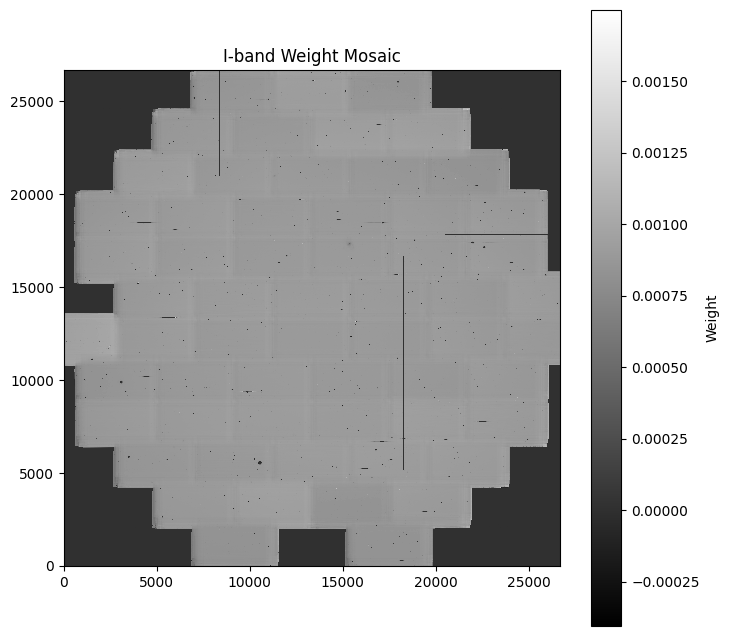

In [6]:
import numpy as np
from astropy.io import fits
import matplotlib.pyplot as plt

# Path to your I-band trimmed FITS
fits_file = '/Users/aishwarya/Documents/Lyman_alpha/i_WEIGHT/fits/weight_mosaic_itrim.fits'

# Open the FITS file
with fits.open(fits_file) as hdu_list:
    hdu = hdu_list[0]  # primary HDU
    data = hdu.data
    header = hdu.header

# Inspect basic info
print("FITS shape:", data.shape)
print("Data type:", data.dtype)
print("Min / Max / Mean:", np.min(data), np.max(data), np.mean(data))

# Optional: display the image with matplotlib
plt.figure(figsize=(8, 8))
plt.imshow(data, origin='lower', cmap='gray', interpolation='nearest')
plt.colorbar(label='Weight')
plt.title('I-band Weight Mosaic')
plt.show()


In [2]:
from astropy.io import fits

files = [
    '/Users/aishwarya/Documents/Lyman_alpha/I/c4d_211021_003551_osj_i_vik2.fits.fz',  # science
    '/Users/aishwarya/Documents/Lyman_alpha/I/c4d_211021_003551_osw_i_vik2.fits.fz',  # weight
]

gain_keys = ['GAIN', 'EGAIN', 'CCDGAIN', 'GAINA', 'GAINB']
ron_keys  = ['RDNOISE', 'READNOIS', 'RON']
unit_keys = ['BUNIT']
extra     = ['EXPTIME', 'FLUXSCAL']

for path in files:
    print(f'\n=== {path} ===')
    with fits.open(path) as hdul:
        for i, hdu in enumerate(hdul):
            if getattr(hdu, 'data', None) is None:
                continue
            hdr = hdu.header
            # Only print if we find something interesting
            found = []
            for k in unit_keys + gain_keys + ron_keys + extra:
                if k in hdr:
                    found.append(f'{k}={hdr[k]}')
            if found:
                print(f'HDU {i:2d} ({hdu.name}): ' + ', '.join(found))



=== /Users/aishwarya/Documents/Lyman_alpha/I/c4d_211021_003551_osj_i_vik2.fits.fz ===

=== /Users/aishwarya/Documents/Lyman_alpha/I/c4d_211021_003551_osw_i_vik2.fits.fz ===


In [5]:
from astropy.io import fits

SCI = '/Users/aishwarya/Documents/Lyman_alpha/I/c4d_211021_003551_osj_i_vik2.fits.fz'
with fits.open(SCI) as hdul:
    hdr1 = hdul[1].header
    print(repr(hdr1))


XTENSION= 'IMAGE   '           / Image extension                                
BITPIX  =                  -32 / Bits per pixel                                 
NAXIS   =                    2 / Number of axes                                 
NAXIS1  =                 9866 / Axis length                                    
NAXIS2  =                 8995 / Axis length                                    
PCOUNT  =                    0 / No 'random' parameters                         
GCOUNT  =                    1 / Only one group                                 
ORIGIN  = 'NOAO-IRAF FITS Image Kernel July 2003' / FITS file originator        
EXTNAME = 'tile11  '           / Extension name                                 
FZQVALUE=                    4                                                  
FZQMETHD= 'SUBTRACTIVE_DITHER_1'                                                
IRAF-TLM= '2023-04-05T19:30:27' / Time of last modification                     
INHERIT =                   

In [6]:
with fits.open(SCI) as hdul:
    hdr0 = hdul[0].header
    print(repr(hdr0))


SIMPLE  =                    T / Fits standard                                  
BITPIX  =                   16 / Bits per pixel                                 
NAXIS   =                    0 / Number of axes                                 
EXTEND  =                    T / File may contain extensions                    
DATE    = '2023-04-05T19:29:59' / Date FITS file was generated                  
ORIGIN  = 'NOAO-IRAF FITS Image Kernel July 2003' / FITS file originator        
COMMENT   FITS (Flexible Image Transport System) format is defined in 'Astronomy
COMMENT   and Astrophysics', volume 376, page 359; bibcode: 2001A&A...376..359H 
COMMENT MODIFIED:DATE,DATE-OBS,DTACQNAM,DTCALDAT,DTINSTRU,DTNSANAM,DTPI,DTPROPID
COMMENT ,DTSITE,DTTELESC,INSTRUME,OBSERVAT,OBSID,OBSTYPE,PROCTYPE,PRODTYPE,PROPI
COMMENT D,SIMPLE,TELESCOP,TIME-OBS                                              
IRAF-TLM= '2023-04-05T19:29:59' / Time of last modification                     
OBJECT  = 'VIK_J2348-3054'  

In [15]:
import numpy as np
from astropy.io import fits
from numpy.random import default_rng

# ---- inputs ----
SCI = '/Users/aishwarya/Documents/Lyman_alpha/I/c4d_211021_003551_osj_i_vik2.fits.fz'
WGT = '/Users/aishwarya/Documents/Lyman_alpha/I/c4d_211021_003551_osw_i_vik2.fits.fz'
ext = 4                # extension you’re analyzing
pixscale = 0.263       # arcsec/pix (DECam)
ap_rad_arcsec = 2.0    # aperture radius
ap_rad_pix = ap_rad_arcsec / pixscale

n_ap = 1000            # number of random sky apertures
seed = 42
rng = default_rng(seed)

# ---- helper: fast circular aperture mask around (yc,xc) with precomputed offsets ----
def circle_offsets(rpix):
    r = int(np.ceil(rpix))
    yy, xx = np.mgrid[-r:r+1, -r:r+1]
    m = (yy*yy + xx*xx) <= rpix*rpix
    return yy[m], xx[m]

dy, dx = circle_offsets(ap_rad_pix)

with fits.open(SCI) as hs, fits.open(WGT) as hw:
    sci = hs[ext].data.astype(float)
    wgt = hw[ext].data.astype(float)

ny, nx = sci.shape

# ---- pick random centers well away from edges and with valid weights ----
margin = int(np.ceil(ap_rad_pix)) + 2
ys = rng.integers(margin, ny - margin, size=n_ap)
xs = rng.integers(margin, nx - margin, size=n_ap)

fluxes = []
var_w = []

for yc, xc in zip(ys, xs):
    yy = yc + dy
    xx = xc + dx
    # guard against any off-image indices (shouldn't happen with margin, but be safe)
    ok = (yy >= 0) & (yy < ny) & (xx >= 0) & (xx < nx)
    yy = yy[ok]; xx = xx[ok]

    ap_vals = sci[yy, xx]
    ap_w = wgt[yy, xx]

    good = np.isfinite(ap_vals) & np.isfinite(ap_w) & (ap_w > 0)
    # require high completeness of good pixels
    if good.sum() < 0.9 * ap_w.size:
        continue

    # subtract local median to avoid large-scale background trends
    # (use a small ring by looking a few pixels farther out)
    # Fallback: use global median if ring would overlap edges or is sparse.
    ring_rad1 = ap_rad_pix*1.5
    ring_rad2 = ap_rad_pix*2.5
    r = np.hypot(np.arange(-int(ring_rad2), int(ring_rad2)+1)[:,None],
                 np.arange(-int(ring_rad2), int(ring_rad2)+1)[None,:])

    y0 = yc - int(ring_rad2); x0 = xc - int(ring_rad2)
    y1 = yc + int(ring_rad2) + 1; x1 = xc + int(ring_rad2) + 1
    if y0 >= 0 and x0 >= 0 and y1 <= ny and x1 <= nx:
        ring = sci[y0:y1, x0:x1]
        ring_m = (r >= ring_rad1) & (r <= ring_rad2)
        ring_vals = ring[ring_m & np.isfinite(ring)]
        if ring_vals.size >= 200:
            sky_med = np.median(ring_vals)
        else:
            sky_med = np.nanmedian(sci[np.isfinite(sci)])
    else:
        sky_med = np.nanmedian(sci[np.isfinite(sci)])

    fluxes.append(np.sum(ap_vals[good] - sky_med))
    var_w.append(np.sum(1.0 / ap_w[good]))

fluxes = np.array(fluxes, dtype=float)
var_w = np.array(var_w, dtype=float)

# robust dispersion of sky-aperture fluxes (image units)
if fluxes.size < 100:
    raise RuntimeError(f"Only {fluxes.size} good sky apertures; increase n_ap or adjust masks.")

med = np.median(fluxes)
mad = np.median(np.abs(fluxes - med))
sigma_flux_img = 1.4826 * mad  # robust sigma of flux sums, in image units

# predicted sigma from weight (image units) per aperture k is sqrt(var_w[k])
# If weights were perfect and noise uncorrelated, sigma_flux_img ~ median(sqrt(var_w))
sigma_pred_img = np.median(np.sqrt(var_w))

# noise-correlation factor for this aperture radius:
# C = (sigma_flux_img^2) / median(var_w)
C = (sigma_flux_img**2) / np.median(var_w)

print(f"Sky apertures used: {fluxes.size}")
print(f"Aperture radius: {ap_rad_arcsec:.2f}\" ({ap_rad_pix:.2f} pix), Npix ≈ {dx.size}")
print(f"Robust sigma of sky-ap flux sums: {sigma_flux_img:.3f} (image units)")
print(f"Median predicted sigma from WEIGHT: {sigma_pred_img:.3f} (image units)")
print(f"Noise-correlation factor  C(r={ap_rad_arcsec:.2f}\") = {C:.3f}")

# ---- How to use C for a real source uncertainty ----
# For any aperture:
#   var_ap_image_units = C * sum(1/W_i)   ->  sigma_ap_image = sqrt(var_ap_image_units)
# If you want electrons and you know/estimate a linear scale s (image-units per e-):
#   var_ap_e = var_ap_image_units / s^2
#   sigma_ap_e = sqrt(var_ap_e)


Sky apertures used: 815
Aperture radius: 2.00" (7.60 pix), Npix ≈ 177
Robust sigma of sky-ap flux sums: 163.614 (image units)
Median predicted sigma from WEIGHT: 444.920 (image units)
Noise-correlation factor  C(r=2.00") = 0.135
